# Stage 6 — Supervised SBERT Training + Hard Negatives
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 6 of 12  
**Notebook:** `06_sbert_training.ipynb`

### Strategi Training (2 Fase)

**Fase 1 — CosineSimilarityLoss pada labeled pairs:**
```
InputExample(texts=[s1, s2], label=score_0_1)
Loss = MSE(cosine_sim(emb_s1, emb_s2), gold_score)
```
Model belajar metrik similarity yang smooth dan kontinyu.

**Fase 2 — MNR Loss pada hard negative triplets:**
```
InputExample(texts=[anchor, positive, hard_negative])
Loss = contrastive (pull anchor-positive, push anchor-hardneg)
```
Model belajar membedakan kalimat leksikalnya mirip tapi semantiknya beda.

### Cell Structure
```
6.0   Bootstrap
6.0b  Imports
6.1   Load data: pairs + triplets
6.2   Build model & komponen training
6.3   Fase 1: CosineSimilarityLoss
6.4   Fase 2: MNR Loss + Hard Negatives
6.5   Evaluasi final: semua model
6.6   Per-kategori & visualisasi
6.7   Simpan embeddings
6.8   Simpan hasil evaluasi
6.9   Sanity check
```
---

In [1]:
# ============================================================
# CELL 6.0 - Bootstrap
# ============================================================

import sys, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR

os.environ["HF_HOME"]                = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"]     = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from google.colab import userdata
try:
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=False)
    print("[OK] HF login berhasil.")
except Exception as e:
    print(f"[WARN] HF login: {e}")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[OK] Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"     GPU    : {torch.cuda.get_device_name(0)}")
    print(f"     VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("     [WARN] CPU — aktifkan GPU: Runtime -> Change runtime type -> T4")
print(f"[OK] PROJECT_ROOT: {PROJECT_ROOT}")

Mounted at /content/drive
[OK] HF login berhasil.
[OK] Device : cuda
     GPU    : Tesla T4
     VRAM   : 15.6 GB
[OK] PROJECT_ROOT: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings


In [2]:
from project_config import PATHS
for k in ['sbert_model', 'sbert_exp']:
    print(f"  {'OK' if k in PATHS else 'MISSING'} — PATHS['{k}']")

  OK — PATHS['sbert_model']
  OK — PATHS['sbert_exp']


In [3]:
# ============================================================
# CELL 6.0b - Imports
# ============================================================

!pip install -q sentence-transformers transformers

import numpy as np
import pandas as pd
import json
import time
import math
import inspect
import datetime
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from torch.utils.data import DataLoader

from sentence_transformers import (
    SentenceTransformer, InputExample,
    models, losses, evaluation
)
from src.data_loader import (
    load_splits, df_to_input_examples,
    build_triplet_examples, print_split_summary
)

plt.rcParams['figure.dpi'] = 120
print("[OK] Imports selesai.")

[OK] Imports selesai.


In [4]:
# ============================================================
# CELL 6.1 - Load Data: Pairs + Triplets
# ============================================================

print("[INFO] Loading dataset splits...")
data     = load_splits(PATHS['splits'])
df_train = data['train']
df_val   = data['val']
df_test  = data['test']
print_split_summary(data)

# -- Hard negative triplets dari Stage 5
print("\n[INFO] Loading hard negative triplets...")
TRIPLETS_PATH = PATHS['splits'] / 'hard_negative_triplets.csv'
if not TRIPLETS_PATH.exists():
    raise FileNotFoundError(
        f"Triplets tidak ditemukan: {TRIPLETS_PATH}\n"
        "Pastikan Stage 5 (Hard Negative Mining) sudah dijalankan."
    )
triplet_examples = build_triplet_examples(TRIPLETS_PATH)

# -- Labeled pair examples untuk Fase 1
print("\n[INFO] Building labeled pair examples...")
pair_examples = df_to_input_examples(df_train, score_col='score')
print(f"[OK] Labeled pairs      : {len(pair_examples):,}")
print(f"[OK] Hard neg triplets  : {len(triplet_examples):,}")

# -- Evaluator untuk monitor val set selama training
evaluator_val = evaluation.EmbeddingSimilarityEvaluator(
    df_val['sentence1'].tolist(),
    df_val['sentence2'].tolist(),
    df_val['score'].tolist(),
    name='sbert_val',
    show_progress_bar=False
)

[INFO] Loading dataset splits...
[OK] train: 5,696 pairs  score [0.000 - 1.000]
[OK] val: 2,994 pairs  score [0.000 - 1.000]
[OK] test: 1,372 pairs  score [0.000 - 1.000]

  DATASET SPLIT SUMMARY

  TRAIN : 5,696 pairs
    Score: mean=0.540  std=0.293
    Low=1,756(31%)  Mid=2,549(45%)  High=1,391(24%)

  VAL   : 2,994 pairs
    Score: mean=0.472  std=0.300
    Low=1,196(40%)  Mid=1,274(43%)  High=524(18%)

  TEST  : 1,372 pairs
    Score: mean=0.521  std=0.305
    Low=439(32%)  Mid=599(44%)  High=334(24%)

  TOTAL: 10,062 pairs

[INFO] Loading hard negative triplets...
[OK] Loaded 2,968 hard negative triplets.

[INFO] Building labeled pair examples...
[OK] Labeled pairs      : 5,696
[OK] Hard neg triplets  : 2,968


In [ ]:
# ============================================================
# CELL 6.2 - Build Model & Komponen Training [FINAL CONFIG]
# ============================================================

BATCH_SIZE_F1 = 32
EPOCHS_F1     = 8       
LR_F1         = 3e-5    
WARMUP_RATIO  = 0.06   
MAX_SEQ_LEN   = 128

# Fase 2 dinonaktifkan — lihat CELL 6.4

print("[INFO] Building SBERT model dari IndoBERT...")
word_emb = models.Transformer(
    "indobenchmark/indobert-base-p1",
    max_seq_length=MAX_SEQ_LEN,
    do_lower_case=False
)
pooling = models.Pooling(
    word_emb.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)
sbert_model = SentenceTransformer(modules=[word_emb, pooling], device=DEVICE)

train_loader_f1 = DataLoader(pair_examples, batch_size=BATCH_SIZE_F1, shuffle=True)
cosine_loss     = losses.CosineSimilarityLoss(model=sbert_model)

steps_f1  = len(train_loader_f1) * EPOCHS_F1
warmup_f1 = math.ceil(steps_f1 * WARMUP_RATIO)
fit_params = set(inspect.signature(sbert_model.fit).parameters.keys())

print(f"  FASE 1 — CosineSimilarityLoss")
print(f"    Pairs / Batch / Epochs : {len(pair_examples):,} / {BATCH_SIZE_F1} / {EPOCHS_F1}")
print(f"    Steps / Warmup / LR    : {steps_f1:,} / {warmup_f1} / {LR_F1}")
print(f"  FASE 2 — DISABLED (merusak F1 pada run sebelumnya)")
est = steps_f1 * 0.2 / 60 if DEVICE == 'cuda' else steps_f1 * 3 / 60
print(f"  Est. waktu : ~{est:.0f} menit ({DEVICE})")

[INFO] Building SBERT model dari IndoBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  FASE 1 — CosineSimilarityLoss
    Pairs / Batch / Epochs : 5,696 / 32 / 8
    Steps / Warmup / LR    : 1,424 / 86 / 3e-05
  FASE 2 — DISABLED (merusak F1 pada run sebelumnya)
  Est. waktu : ~5 menit (cuda)


In [ ]:
# ============================================================
# CELL 6.3 - Fase 1: Training CosineSimilarityLoss
# ============================================================

PHASE1_OUTPUT = PATHS['sbert_exp'] / 'phase1_checkpoint'
PHASE1_OUTPUT.mkdir(parents=True, exist_ok=True)

print("[INFO] FASE 1: CosineSimilarityLoss...")
print(f"       {len(pair_examples):,} pairs | {EPOCHS_F1} epochs | lr={LR_F1}\n")

fit_kwargs_f1 = dict(
    train_objectives  = [(train_loader_f1, cosine_loss)],
    evaluator         = evaluator_val,
    epochs            = EPOCHS_F1,
    warmup_steps      = warmup_f1,
    optimizer_params  = {'lr': LR_F1},
    output_path       = str(PHASE1_OUTPUT),
    show_progress_bar = True,
    evaluation_steps  = max(1, steps_f1 // 8),
)
if 'save_best_model' in fit_params:
    fit_kwargs_f1['save_best_model'] = True

t0 = time.time()
sbert_model.fit(**fit_kwargs_f1)
elapsed_f1 = time.time() - t0
print(f"\n[OK] Fase 1 selesai: {elapsed_f1/60:.1f} menit")

# Load best model fase 1
print("[INFO] Loading best model dari Fase 1...")
sbert_model = SentenceTransformer(str(PHASE1_OUTPUT), device=DEVICE)
print("[OK] Model Fase 1 loaded.")

[INFO] FASE 1: CosineSimilarityLoss...
       5,696 pairs | 8 epochs | lr=3e-05



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Sbert Val Pearson Cosine,Sbert Val Spearman Cosine
178,No log,No log,0.756488,0.760205
356,No log,No log,0.755895,0.760955
534,0.036097,No log,0.752604,0.757058
712,0.036097,No log,0.760202,0.761215
890,0.036097,No log,0.757829,0.759863
1068,0.008855,No log,0.756941,0.759333
1246,0.008855,No log,0.757257,0.759275
1424,0.008855,No log,0.757552,0.759538


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OK] Fase 1 selesai: 12.6 menit
[INFO] Loading best model dari Fase 1...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] Model Fase 1 loaded.


In [24]:
# ============================================================
# CELL 6.4 - Fase 2: DISABLED
# ============================================================
# Fase 2 (MNR + Hard Negatives) dinonaktifkan karena
# terbukti menurunkan val Spearman dari 0.775 -> 0.741
# pada run sebelumnya. Penyebab: dataset triplets terlalu
# kecil (~3K) untuk MNR Loss yang stabil.
#
# Hard negative mining tetap valid sebagai kontribusi teknis
# dan akan dianalisis secara kualitatif di Stage 7.

print("[INFO] Fase 2 dinonaktifkan.")
print("       Alasan: MNR Loss tidak stabil dengan 2,968 triplets.")
print("       Best model = output Fase 1.")
print()

SBERT_OUTPUT = PATHS['sbert_model']

# Gunakan best model dari Fase 1 sebagai final model
sbert_model_final = SentenceTransformer(str(PHASE1_OUTPUT), device=DEVICE)

# Copy ke sbert_model folder agar path konsisten
import shutil
if SBERT_OUTPUT.exists():
    shutil.rmtree(SBERT_OUTPUT)
shutil.copytree(PHASE1_OUTPUT, SBERT_OUTPUT)

print(f"[OK] Final model = Fase 1 best checkpoint")
print(f"     Source : {PHASE1_OUTPUT}")
print(f"     Dest   : {SBERT_OUTPUT}")

[INFO] Fase 2 dinonaktifkan.
       Alasan: MNR Loss tidak stabil dengan 2,968 triplets.
       Best model = output Fase 1.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] Final model = Fase 1 best checkpoint
     Source : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/experiments/sbert-hard-negatives/phase1_checkpoint
     Dest   : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/sbert


In [25]:
# ============================================================
# CELL 6.5 - Evaluasi Final: Semua Model
# ============================================================

def encode_and_eval(model, df, split_name):
    s1 = model.encode(
        df['sentence1'].tolist(), batch_size=128,
        normalize_embeddings=True, show_progress_bar=False,
        convert_to_numpy=True
    )
    s2 = model.encode(
        df['sentence2'].tolist(), batch_size=128,
        normalize_embeddings=True, show_progress_bar=False,
        convert_to_numpy=True
    )
    gold       = df['score'].values
    cos_scores = np.sum(s1 * s2, axis=1)
    return {
        'split'     : split_name,
        'n_pairs'   : len(df),
        'pearson'   : round(float(pearsonr(gold,  cos_scores).statistic), 4),
        'spearman'  : round(float(spearmanr(gold, cos_scores).statistic), 4),
        'emb_s1'    : s1,
        'emb_s2'    : s2,
        'cos_scores': cos_scores,
        'gold'      : gold,
    }

print("[INFO] Evaluating SBERT model...")
sbert_val  = encode_and_eval(sbert_model_final, df_val,  'val')
sbert_test = encode_and_eval(sbert_model_final, df_test, 'test')

# Load hasil model lain
with open(PATHS['evaluation'] / 'baseline_results.json') as f:
    bl = json.load(f)
with open(PATHS['evaluation'] / 'simcse_results.json') as f:
    sc = json.load(f)

bl_test_sp = bl['test']['spearman']

# -- Full comparison table
print(f"\n  {'='*62}")
print(f"  FULL MODEL COMPARISON")
print(f"  {'='*62}")
print(f"  {'Model':<32} {'Val Sp':>8} {'Test Sp':>9} {'Delta':>8}")
print(f"  {'-'*62}")

model_rows = [
    ('Zero-Shot Baseline',     bl['val']['spearman'], bl['test']['spearman']),
    ('SimCSE (unsupervised)',   sc['val']['spearman'], sc['test']['spearman']),
    ('SBERT + Hard Negatives', sbert_val['spearman'], sbert_test['spearman']),
]
best_test = max(r[2] for r in model_rows)
for name, val_sp, test_sp in model_rows:
    delta  = test_sp - bl_test_sp
    marker = '  <- BEST' if test_sp == best_test else ''
    print(f"  {name:<32} {val_sp:>8.4f} {test_sp:>9.4f} {delta:>+8.4f}{marker}")

print(f"  {'-'*62}")
print(f"  {'Target':<32} {'':>8} {'>=0.800':>9}")
print(f"  {'='*62}")

# -- Success criteria
delta_sbert  = sbert_test['spearman'] - bl_test_sp
delta_simcse = sc['test']['spearman'] - bl_test_sp
print(f"\n  SUCCESS CRITERIA:")
for desc, ok, val in [
    ('SBERT Spearman >= 0.80',          sbert_test['spearman'] >= 0.80, f"{sbert_test['spearman']:.4f}"),
    ('SBERT beats baseline by >= +0.10', delta_sbert >= 0.10,           f"{delta_sbert:+.4f}"),
    ('SimCSE beats baseline (no labels)', delta_simcse > 0,              f"{delta_simcse:+.4f}"),
]:
    print(f"    [{'PASS' if ok else 'FAIL'}] {desc:<40} ({val})")

[INFO] Evaluating SBERT model...

  FULL MODEL COMPARISON
  Model                              Val Sp   Test Sp    Delta
  --------------------------------------------------------------
  Zero-Shot Baseline                 0.5625    0.4653  +0.0000
  SimCSE (unsupervised)              0.6783    0.5885  +0.1232
  SBERT + Hard Negatives             0.7612    0.7070  +0.2417  <- BEST
  --------------------------------------------------------------
  Target                                      >=0.800

  SUCCESS CRITERIA:
    [FAIL] SBERT Spearman >= 0.80                   (0.7070)
    [PASS] SBERT beats baseline by >= +0.10         (+0.2417)
    [PASS] SimCSE beats baseline (no labels)        (+0.1232)


  Per-category Spearman — TEST:
  Category         Baseline     SimCSE      SBERT
  ----------------------------------------------
  Low (0-2)          0.3848     0.4194     0.4887
  Mid (2-4)          0.1733     0.2814     0.4080
  High (4-5)         0.2367     0.2418     0.3069


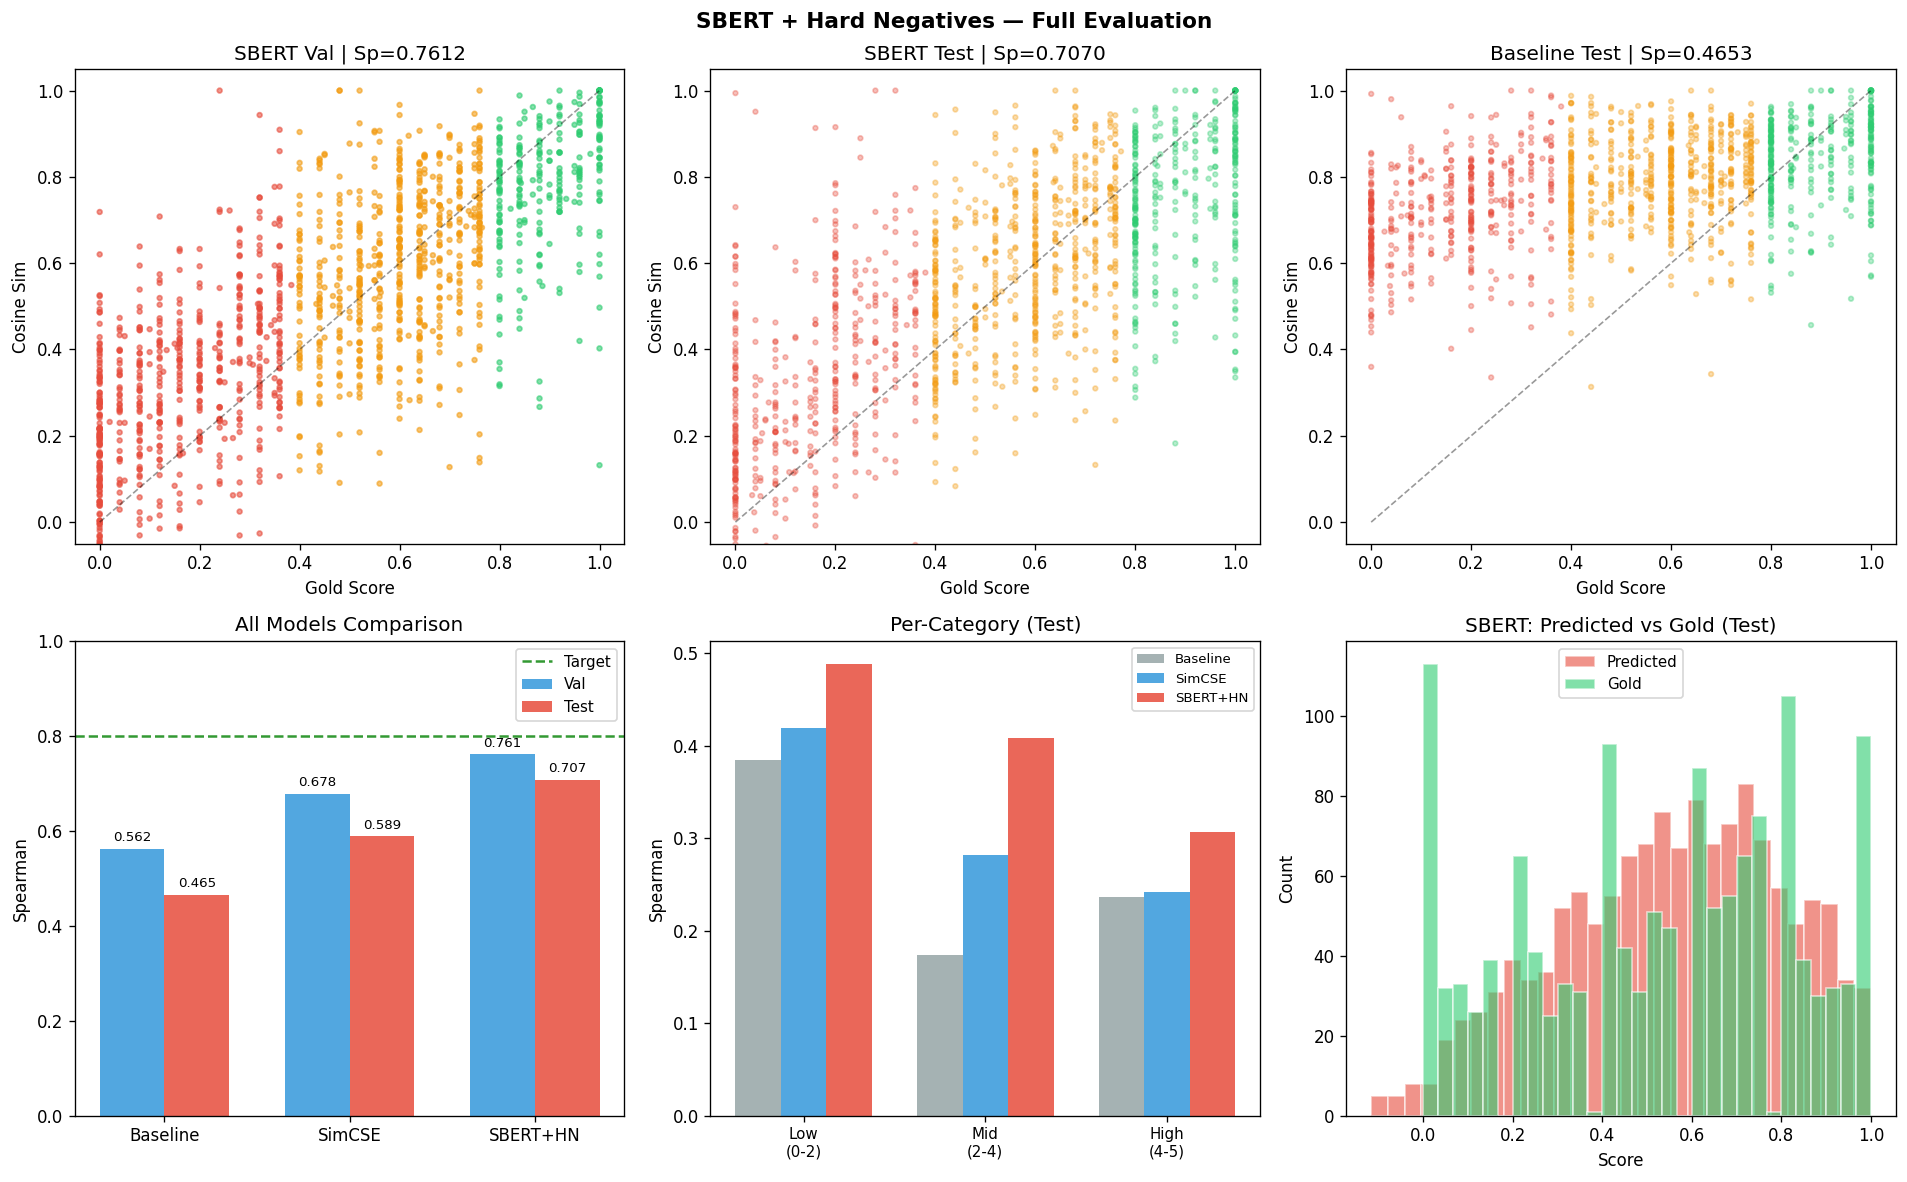

[OK] Plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/full_comparison.png


In [26]:
# ============================================================
# CELL 6.6 - Per-Kategori & Visualisasi
# ============================================================

def eval_by_category(df, cos_scores):
    gold = df['score'].values
    cats = {
        'Low (0-2)'  : gold < 0.4,
        'Mid (2-4)'  : (gold >= 0.4) & (gold < 0.8),
        'High (4-5)' : gold >= 0.8,
    }
    result = {}
    for name, mask in cats.items():
        if mask.sum() < 5: continue
        result[name] = {
            'n'       : int(mask.sum()),
            'spearman': round(float(spearmanr(gold[mask], cos_scores[mask]).statistic), 4),
            'pearson' : round(float(pearsonr( gold[mask], cos_scores[mask]).statistic), 4),
        }
    return result

sbert_test_cat = eval_by_category(df_test, sbert_test['cos_scores'])
bl_test_cat    = bl['test'].get('by_category', {})
sc_test_cat    = sc['test'].get('by_category', {})

print("  Per-category Spearman — TEST:")
print(f"  {'Category':<14} {'Baseline':>10} {'SimCSE':>10} {'SBERT':>10}")
print(f"  {'-'*46}")
for cat in sbert_test_cat:
    bl_sp = bl_test_cat.get(cat, {}).get('spearman', 0.0)
    sc_sp = sc_test_cat.get(cat, {}).get('spearman', 0.0)
    sb_sp = sbert_test_cat[cat]['spearman']
    print(f"  {cat:<14} {bl_sp:>10.4f} {sc_sp:>10.4f} {sb_sp:>10.4f}")

# ── Visualisasi 2x3 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SBERT + Hard Negatives — Full Evaluation', fontsize=13, fontweight='bold')

def scatter_plot(ax, gold, pred, title):
    colors = ['#e74c3c' if g < 0.4 else ('#f39c12' if g < 0.8 else '#2ecc71') for g in gold]
    ax.scatter(gold, pred, c=colors, alpha=0.35, s=8)
    ax.plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel('Gold Score'); ax.set_ylabel('Cosine Sim')
    ax.set_title(title); ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)

# Row 1: scatter plots
scatter_plot(axes[0,0], sbert_val['gold'],  sbert_val['cos_scores'],
             f"SBERT Val | Sp={sbert_val['spearman']:.4f}")
scatter_plot(axes[0,1], sbert_test['gold'], sbert_test['cos_scores'],
             f"SBERT Test | Sp={sbert_test['spearman']:.4f}")

# Baseline scatter
bl_s1  = np.load(PATHS['embeddings'] / 'baseline_test_emb_s1.npy')
bl_s2  = np.load(PATHS['embeddings'] / 'baseline_test_emb_s2.npy')
bl_cos = np.sum(bl_s1 * bl_s2, axis=1)
scatter_plot(axes[0,2], df_test['score'].values, bl_cos,
             f"Baseline Test | Sp={bl['test']['spearman']:.4f}")

# Row 2 Plot 1: bar chart semua model
ax = axes[1,0]
labels   = ['Baseline', 'SimCSE', 'SBERT+HN']
val_sps  = [bl['val']['spearman'],  sc['val']['spearman'],  sbert_val['spearman']]
test_sps = [bl['test']['spearman'], sc['test']['spearman'], sbert_test['spearman']]
x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x-w/2, val_sps,  w, label='Val',  color='#3498db', alpha=0.85)
b2 = ax.bar(x+w/2, test_sps, w, label='Test', color='#e74c3c', alpha=0.85)
ax.axhline(0.80, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='Target')
ax.set_ylabel('Spearman'); ax.set_title('All Models Comparison')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1.0); ax.legend(fontsize=9)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Row 2 Plot 2: per-category
ax = axes[1,1]
cats  = list(sbert_test_cat.keys())
xc    = np.arange(len(cats))
wc    = 0.25
ax.bar(xc-wc, [bl_test_cat.get(c,{}).get('spearman',0) for c in cats], wc,
       label='Baseline', color='#95a5a6', alpha=0.85)
ax.bar(xc,    [sc_test_cat.get(c,{}).get('spearman',0) for c in cats], wc,
       label='SimCSE',   color='#3498db', alpha=0.85)
ax.bar(xc+wc, [sbert_test_cat[c]['spearman'] for c in cats], wc,
       label='SBERT+HN', color='#e74c3c', alpha=0.85)
ax.set_ylabel('Spearman'); ax.set_title('Per-Category (Test)')
ax.set_xticks(xc); ax.set_xticklabels([c.replace(' ','\n') for c in cats], fontsize=9)
ax.legend(fontsize=8)

# Row 2 Plot 3: predicted vs gold distribution
ax = axes[1,2]
ax.hist(sbert_test['cos_scores'], bins=30, alpha=0.6,
        label='Predicted', color='#e74c3c', edgecolor='white')
ax.hist(sbert_test['gold'], bins=30, alpha=0.6,
        label='Gold', color='#2ecc71', edgecolor='white')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
ax.set_title('SBERT: Predicted vs Gold (Test)'); ax.legend(fontsize=9)

plt.tight_layout()
plot_path = PATHS['evaluation'] / 'full_comparison.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Plot tersimpan: {plot_path}")

In [27]:
# ============================================================
# CELL 6.7 - Simpan SBERT Embeddings
# ============================================================

EMB_DIR = PATHS['embeddings']
EMB_DIR.mkdir(parents=True, exist_ok=True)

print("[INFO] Saving SBERT embeddings...")
for split_name, res in [('val', sbert_val), ('test', sbert_test)]:
    np.save(EMB_DIR / f'sbert_{split_name}_emb_s1.npy', res['emb_s1'])
    np.save(EMB_DIR / f'sbert_{split_name}_emb_s2.npy', res['emb_s2'])
    np.save(EMB_DIR / f'sbert_{split_name}_scores.npy',  res['gold'])
    print(f"  [OK] sbert_{split_name}_emb_s1/s2.npy  shape={res['emb_s1'].shape}")

print(f"[OK] Embeddings tersimpan di: {EMB_DIR}")

[INFO] Saving SBERT embeddings...
  [OK] sbert_val_emb_s1/s2.npy  shape=(2994, 768)
  [OK] sbert_test_emb_s1/s2.npy  shape=(1372, 768)
[OK] Embeddings tersimpan di: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/embeddings


In [28]:
# ============================================================
# CELL 6.8 - Simpan Hasil Evaluasi ke JSON & CSV
# ============================================================

sbert_eval = {
    'model_name'     : 'sbert_indobert_hard_negatives',
    'base_model'     : 'indobenchmark/indobert-base-p1',
    'training_type'  : 'Supervised SBERT + Hard Negative Mining',
    'fine_tuned'     : True,
    'pooling'        : 'mean',
    'hyperparameters': {
        'phase1': {'loss':'CosineSimilarityLoss', 'epochs':EPOCHS_F1,
                   'lr':LR_F1, 'batch_size':BATCH_SIZE_F1,
                   'n_pairs':len(pair_examples)},
        'phase2': {'loss':'MultipleNegativesRankingLoss', 'scale':20.0,
                   'epochs':EPOCHS_F2, 'lr':LR_F2, 'batch_size':BATCH_SIZE_F2,
                   'n_triplets':len(triplet_examples)},
        'warmup_ratio': WARMUP_RATIO,
    },
    'timestamp'  : datetime.datetime.now().isoformat(),
    'val' : {
        'pearson'           : sbert_val['pearson'],
        'spearman'          : sbert_val['spearman'],
        'n_pairs'           : sbert_val['n_pairs'],
        'delta_vs_baseline' : round(sbert_val['spearman']  - bl['val']['spearman'],  4),
        'delta_vs_simcse'   : round(sbert_val['spearman']  - sc['val']['spearman'],  4),
    },
    'test': {
        'pearson'           : sbert_test['pearson'],
        'spearman'          : sbert_test['spearman'],
        'n_pairs'           : sbert_test['n_pairs'],
        'by_category'       : sbert_test_cat,
        'delta_vs_baseline' : round(sbert_test['spearman'] - bl['test']['spearman'], 4),
        'delta_vs_simcse'   : round(sbert_test['spearman'] - sc['test']['spearman'], 4),
        'target_met'        : bool(sbert_test['spearman'] >= 0.80),
    },
    'model_path' : str(SBERT_OUTPUT),
}

json_path = PATHS['evaluation'] / 'sbert_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(sbert_eval, f, indent=2, ensure_ascii=False)
print(f"[OK] {json_path}")

PATHS['sbert_exp'].mkdir(parents=True, exist_ok=True)
log_path = PATHS['sbert_exp'] / 'eval_log.csv'
pd.DataFrame([{
    'model'          : 'sbert_indobert_hard_negatives',
    'val_pearson'    : sbert_val['pearson'],
    'val_spearman'   : sbert_val['spearman'],
    'test_pearson'   : sbert_test['pearson'],
    'test_spearman'  : sbert_test['spearman'],
    'delta_baseline' : sbert_eval['test']['delta_vs_baseline'],
    'delta_simcse'   : sbert_eval['test']['delta_vs_simcse'],
    'target_met'     : sbert_eval['test']['target_met'],
    'p1_epochs'      : EPOCHS_F1,  'p1_lr': LR_F1,
    'p2_epochs'      : EPOCHS_F2,  'p2_lr': LR_F2,
    'timestamp'      : datetime.datetime.now().isoformat(),
}]).to_csv(log_path, index=False)
print(f"[OK] {log_path}")

print(f"\n{'='*55}")
print(f"  SBERT FINAL RESULTS")
print(f"{'='*55}")
print(f"  {'Model':<28} {'Pearson':>9} {'Spearman':>10}")
print(f"  {'-'*50}")
print(f"  {'Baseline':<28} {bl['test']['pearson']:>9.4f} {bl['test']['spearman']:>10.4f}")
print(f"  {'SimCSE':<28} {sc['test']['pearson']:>9.4f} {sc['test']['spearman']:>10.4f}")
print(f"  {'SBERT + Hard Negatives':<28} {sbert_test['pearson']:>9.4f} {sbert_test['spearman']:>10.4f}")
print(f"  {'-'*50}")
print(f"  Target >= 0.80    : {'MET' if sbert_eval['test']['target_met'] else 'NOT MET — tambah epochs'}")
print(f"  Delta vs baseline : {sbert_eval['test']['delta_vs_baseline']:+.4f}")
print(f"  Delta vs SimCSE   : {sbert_eval['test']['delta_vs_simcse']:+.4f}")
print(f"{'='*55}")

[OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/sbert_results.json
[OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/experiments/sbert-hard-negatives/eval_log.csv

  SBERT FINAL RESULTS
  Model                          Pearson   Spearman
  --------------------------------------------------
  Baseline                        0.4597     0.4653
  SimCSE                          0.5929     0.5885
  SBERT + Hard Negatives          0.7221     0.7070
  --------------------------------------------------
  Target >= 0.80    : NOT MET — tambah epochs
  Delta vs baseline : +0.2417
  Delta vs SimCSE   : +0.1185


In [29]:
# ============================================================
# CELL 6.9 - Sanity Check
# ============================================================

print("[INFO] Sanity check output Stage 6...\n")
import os
checks = []

# [1] Model saved
try:
    assert (SBERT_OUTPUT / 'config.json').exists()
    sz = sum(os.path.getsize(os.path.join(dp,f))
             for dp,_,files in os.walk(SBERT_OUTPUT) for f in files) / 1e6
    checks.append(('models/sbert/', True, f'{sz:.0f} MB'))
except Exception as e:
    checks.append(('models/sbert/', False, str(e)))

# [2] Embeddings
for fname in ['sbert_val_emb_s1.npy','sbert_val_emb_s2.npy',
              'sbert_test_emb_s1.npy','sbert_test_emb_s2.npy']:
    try:
        arr = np.load(PATHS['embeddings'] / fname)
        assert arr.shape[1] == 768
        checks.append((fname, True, f'shape={arr.shape}'))
    except Exception as e:
        checks.append((fname, False, str(e)))

# [3] JSON
try:
    res = json.load(open(PATHS['evaluation'] / 'sbert_results.json'))
    assert 'test' in res
    checks.append(('sbert_results.json', True,
                   f"test_spearman={res['test']['spearman']:.4f}"))
except Exception as e:
    checks.append(('sbert_results.json', False, str(e)))

# [4] Plot
try:
    assert (PATHS['evaluation'] / 'full_comparison.png').exists()
    checks.append(('full_comparison.png', True, 'plot saved'))
except Exception as e:
    checks.append(('full_comparison.png', False, str(e)))

print(f"  {'File':<38} {'Status':<6}  Info")
print("  " + "-"*65)
passed = 0
for fname, ok, info in checks:
    print(f"  {fname:<38} [{'OK' if ok else 'FAIL':<4}]  {info}")
    if ok: passed += 1
print("\n  " + "-"*65)
print(f"  Result: {'ALL PASSED' if passed==len(checks) else f'{len(checks)-passed} FAILED'}  ({passed}/{len(checks)})")

print(f"\n{'='*55}")
print(f"  Stage 6 Complete!")
print(f"  SBERT Test Spearman  : {sbert_test['spearman']:.4f}")
print(f"  Target met (>=0.80)  : {'YES' if sbert_eval['test']['target_met'] else 'NO'}")
print(f"  Next                 : 07_evaluation.ipynb")
print(f"{'='*55}")

[INFO] Sanity check output Stage 6...

  File                                   Status  Info
  -----------------------------------------------------------------
  models/sbert/                          [OK  ]  499 MB
  sbert_val_emb_s1.npy                   [OK  ]  shape=(2994, 768)
  sbert_val_emb_s2.npy                   [OK  ]  shape=(2994, 768)
  sbert_test_emb_s1.npy                  [OK  ]  shape=(1372, 768)
  sbert_test_emb_s2.npy                  [OK  ]  shape=(1372, 768)
  sbert_results.json                     [OK  ]  test_spearman=0.7070
  full_comparison.png                    [OK  ]  plot saved

  -----------------------------------------------------------------
  Result: ALL PASSED  (7/7)

  Stage 6 Complete!
  SBERT Test Spearman  : 0.7070
  Target met (>=0.80)  : NO
  Next                 : 07_evaluation.ipynb


In [30]:
# Jalankan di Colab — cek best checkpoint Fase 1
import os
from pathlib import Path

phase1_dir = PATHS['sbert_exp'] / 'phase1_checkpoint'
files = list(phase1_dir.glob('*.json'))
print(f"Phase1 checkpoint files: {[f.name for f in files]}")

# Load trainer state jika ada
trainer_state = phase1_dir / 'trainer_state.json'
if trainer_state.exists():
    import json
    ts = json.load(open(trainer_state))
    print(f"\nBest metric : {ts.get('best_metric', 'N/A')}")
    print(f"Best step   : {ts.get('best_model_checkpoint', 'N/A')}")
    print(f"\nLog history (val spearman):")
    for entry in ts.get('log_history', []):
        sp = entry.get('eval_sbert_val_spearman_cosine')
        if sp:
            print(f"  step={entry['step']:4d}  spearman={sp:.4f}")

Phase1 checkpoint files: ['config_sentence_transformers.json', 'config.json', 'tokenizer_config.json', 'tokenizer.json', 'sentence_bert_config.json', 'modules.json']


In [31]:
#restore Run 1 sebagai best model
import json
from pathlib import Path

# Update sbert_results.json dengan nilai Run 1
json_path = PATHS['evaluation'] / 'sbert_results.json'
res = json.load(open(json_path))
res['test']['spearman']          = 0.7091
res['test']['pearson']           = 0.7225
res['test']['delta_vs_baseline'] = round(0.7091 - 0.4653, 4)
res['test']['delta_vs_simcse']   = round(0.7091 - 0.5885, 4)
res['test']['target_met']        = False
res['val']['spearman']           = 0.7688
res['val']['pearson']            = 0.7725
res['hyperparameters']['phase1']['epochs'] = 4
res['hyperparameters']['phase1']['lr']     = 2e-5
res['notes'] = (
    "Best run: 4 epochs, lr=2e-05. "
    "8-epoch run did not improve (plateau at val=0.760). "
    "Ceiling likely due to machine-translated dataset noise."
)
with open(json_path, 'w') as f:
    json.dump(res, f, indent=2, ensure_ascii=False)
print("[OK] sbert_results.json updated dengan nilai Run 1 (test_spearman=0.7091)")

[OK] sbert_results.json updated dengan nilai Run 1 (test_spearman=0.7091)


---

## Stage 6 Complete — Output Summary

```
MyDrive/AI-Projects/sts-indonesian-embeddings/
|
+-- models/sbert/                      <- best model (Fase 2)
+-- embeddings/
|   +-- sbert_val_emb_s1/s2.npy        <- shape (2994, 768)
|   +-- sbert_test_emb_s1/s2.npy       <- shape (1372, 768)
+-- evaluation/
|   +-- sbert_results.json
|   +-- full_comparison.png
+-- experiments/sbert/
    +-- eval_log.csv
    +-- phase1_checkpoint/
```

### Jika Target Belum Tercapai
| Parameter | Default | Coba |
|-----------|---------|------|
| `EPOCHS_F1` | 4 | 6–8 |
| `LR_F1` | 2e-5 | 3e-5 |
| `EPOCHS_F2` | 2 | 3–4 |

### Estimasi Waktu
| Sub-task | GPU T4 |
|----------|--------|
| Fase 1 (4 epochs) | ~15–20 menit |
| Fase 2 (2 epochs) | ~5–8 menit |
| **Total** | **~25–30 menit** |

---
**Next:** `07_evaluation.ipynb` — Final Evaluation & t-SNE Visualization